# PatchTST — ECG Multi-Label Classification
## PTB-XL+ · 500 Hz · 5 classes: NORM, MI, STTC, CD, HYP

## Celda 1 · Imports y configuración

In [1]:
import sys, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, precision_score,
    recall_score, accuracy_score, average_precision_score,
    precision_recall_curve, confusion_matrix,
    multilabel_confusion_matrix,
)
from tqdm.auto import tqdm

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

MODEL_NAME      = "patchtst"
SAMPLING_RATE   = 500
BATCH_SIZE      = 64
NUM_WORKERS     = 0
EPOCHS          = 100
PATIENCE        = 25
LR              = 1e-3
WEIGHT_DECAY    = 1e-4
CLASS_NAMES     = ["NORM", "MI", "STTC", "CD", "HYP"]

DATA_PATH       = PROJECT_ROOT / "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"
RESULTS_DIR     = PROJECT_ROOT / "results"
FIGURES_DIR     = RESULTS_DIR / "figures"
METRICS_DIR     = RESULTS_DIR / "metrics"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"

for d in [FIGURES_DIR, METRICS_DIR, CHECKPOINTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12})
print(f"Results → {RESULTS_DIR}")


Device: cuda
Results → C:\Personal\UP\ML2\ecg-classification\results


## Celda 2 · Dataset, normalización y DataLoaders

Loaded pre-computed norm stats from C:\Personal\UP\ML2\ecg-classification\config\norm_stats.npy
Saved normalizer stats to C:\Personal\UP\ML2\ecg-classification\results\metrics\patchtst_norm_stats.npy
pos_weight: tensor([1.2930, 2.9776, 3.2618, 3.4582, 7.2199])

Split sizes → train:17418, val:2183, test:2198
Batch shape → X:torch.Size([64, 12, 5000]), y:torch.Size([64, 5])


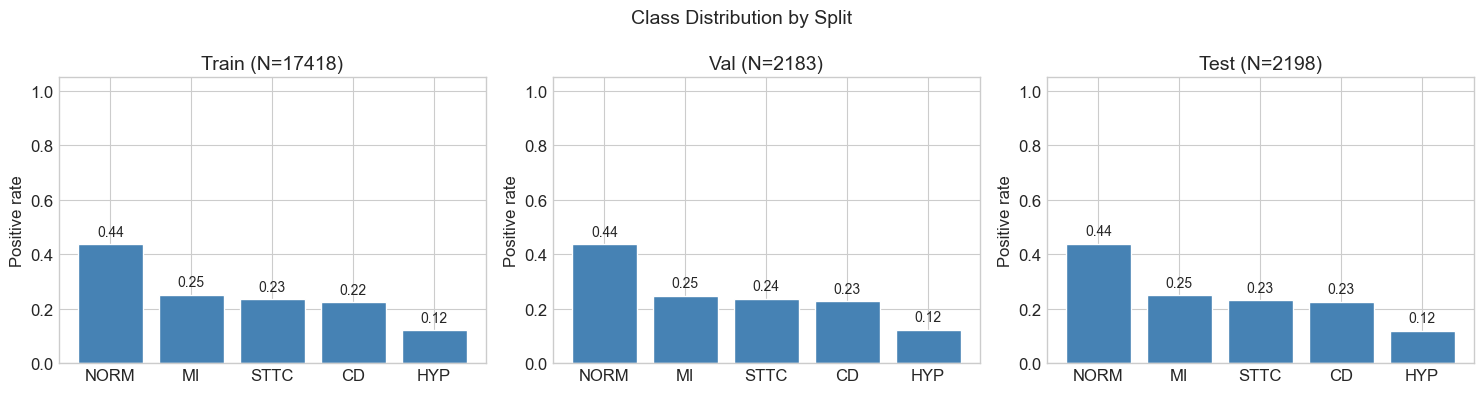

In [2]:
from data.dataset import PTBXLDataset
from data.preprocessing import (
    fit_normalizer, normalize, save_norm_stats, load_norm_stats,
    default_train_transforms,
)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH}\n"
        "Download PTB-XL+ from PhysioNet and place it in the project root."
    )

# ── Normalization stats ────────────────────────────────────────────
# Uses pre-computed stats from scripts/preprocess.py by default.
# Set use_precomputed=False to recompute (requires ~4 GB RAM).
use_precomputed = True
config_stats = PROJECT_ROOT / "config" / "norm_stats.npy"

if use_precomputed and config_stats.exists():
    mean, std = load_norm_stats(config_stats)
    print(f"Loaded pre-computed norm stats from {config_stats}")
else:
    print("Computing norm stats from training set (may take a while)…")
    _tmp_ds = PTBXLDataset(DATA_PATH, split="train", sampling_rate=SAMPLING_RATE)
    _tmp_loader = DataLoader(_tmp_ds, batch_size=64, shuffle=False, num_workers=0)
    _X_list = []
    for _X, _ in tqdm(_tmp_loader, desc="Loading train signals"):
        _X_list.append(_X.numpy())
    _X_train = np.concatenate(_X_list, axis=0)   # (N, 12, L)
    mean, std = fit_normalizer(_X_train)
    del _X_train, _X_list
    print(f"Computed norm stats. mean.shape={mean.shape}")

save_norm_stats(mean, std, METRICS_DIR / f"{MODEL_NAME}_norm_stats.npy")
norm_stats = (mean, std)

# ── pos_weight ─────────────────────────────────────────────────────
pos_weight_path = PROJECT_ROOT / "data" / "processed" / "pos_weight.npy"
if not pos_weight_path.exists():
    raise FileNotFoundError(
        f"pos_weight.npy not found: {pos_weight_path}\n"
        "Run: python scripts/preprocess.py"
    )
pos_weight = torch.tensor(np.load(str(pos_weight_path)), dtype=torch.float32)
print(f"pos_weight: {pos_weight}")

# ── Datasets & DataLoaders ─────────────────────────────────────────
train_transform = default_train_transforms(signal_length=5000)

train_ds = PTBXLDataset(DATA_PATH, split="train", sampling_rate=SAMPLING_RATE,
                         transform=train_transform, norm_stats=norm_stats)
val_ds   = PTBXLDataset(DATA_PATH, split="val",   sampling_rate=SAMPLING_RATE,
                         norm_stats=norm_stats)
test_ds  = PTBXLDataset(DATA_PATH, split="test",  sampling_rate=SAMPLING_RATE,
                         norm_stats=norm_stats)

print(f"\nSplit sizes → train:{len(train_ds)}, val:{len(val_ds)}, test:{len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")

X_s, y_s = next(iter(train_loader))
print(f"Batch shape → X:{X_s.shape}, y:{y_s.shape}")

# ── Class distribution bar chart ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (ds, title) in zip(axes, [(train_ds,"Train"),(val_ds,"Val"),(test_ds,"Test")]):
    labels = ds.get_all_labels()
    freqs  = labels.mean(axis=0)
    bars   = ax.bar(CLASS_NAMES, freqs, color="steelblue", edgecolor="white")
    ax.set_title(f"{title} (N={len(ds)})")
    ax.set_ylabel("Positive rate")
    ax.set_ylim(0, 1.05)
    for bar, f in zip(bars, freqs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{f:.2f}", ha="center", va="bottom", fontsize=10)
plt.suptitle("Class Distribution by Split", fontsize=14)
plt.tight_layout()
plt.show()


## Celda 3 · Modelo

In [3]:
from models.patchtst import PatchTST

try:
    from torchinfo import summary as tinfo_summary
    HAS_TORCHINFO = True
except ImportError:
    HAS_TORCHINFO = False
    print("torchinfo not installed. pip install torchinfo")

model = PatchTST(
    n_classes=5, n_leads=12, signal_length=5000,
    patch_size=50, stride=50, d_model=256,
    n_heads=8, n_layers=6, ff_dim=1024,
    attn_dropout=0.1, dropout=0.1,
).to(device)

if HAS_TORCHINFO:
    tinfo_summary(model, input_size=(BATCH_SIZE, 12, 5000),
                  col_names=["input_size","output_size","num_params","mult_adds"], depth=4)
else:
    n  = sum(p.numel() for p in model.parameters())
    nt = sum(p.numel() for p in model.parameters() if p.requires_grad)
    sz = sum(p.numel()*p.element_size() for p in model.parameters()) / 1e6
    print(f"Total params:     {n:,}")
    print(f"Trainable params: {nt:,}")
    print(f"Model size (MB):  {sz:.1f}")
    print(f"Patches per lead: {model.n_patches}")


C:\Personal\UP\ML2\ecg-classification\models\patchtst.py:123: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


## Celda 4 · Entrenamiento

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
scaler    = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

history = {"train_loss":[], "val_loss":[], "val_macro_auc":[], "val_macro_f1":[], "learning_rate":[]}
best_auc, best_epoch, patience_counter = 0.0, 0, 0
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_best.pt"
t0 = time.time()

for epoch in range(EPOCHS):
    # ── train ──────────────────────────────────────────────────────
    model.train()
    train_losses = []
    for X, y in tqdm(train_loader, desc=f"Ep {epoch+1}/{EPOCHS} [train]", leave=False):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast('cuda'):
                loss = criterion(model(X), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
        train_losses.append(loss.item())

    # ── validate ───────────────────────────────────────────────────
    model.eval()
    val_losses, vl, vt = [], [], []
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            val_losses.append(criterion(logits, y).item())
            vl.append(torch.sigmoid(logits).cpu())
            vt.append(y.cpu())

    vp = torch.cat(vl).numpy()
    vy = torch.cat(vt).numpy()
    val_auc = float(roc_auc_score(vy, vp, average="macro"))
    val_f1  = float(f1_score(vy, (vp >= 0.5).astype(int), average="macro", zero_division=0))

    history["train_loss"].append(float(np.mean(train_losses)))
    history["val_loss"].append(float(np.mean(val_losses)))
    history["val_macro_auc"].append(val_auc)
    history["val_macro_f1"].append(val_f1)
    history["learning_rate"].append(scheduler.get_last_lr()[0])
    scheduler.step()

    # ── checkpoint + early stopping ────────────────────────────────
    if val_auc > best_auc:
        best_auc, best_epoch, patience_counter = val_auc, epoch, 0
        torch.save({
            "epoch": epoch, "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_auc": val_auc, "history": history,
        }, ckpt_path)
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break

    print(f"Ep {epoch+1:3d} | train={history['train_loss'][-1]:.4f} "
          f"| val={history['val_loss'][-1]:.4f} | auc={val_auc:.4f} | f1={val_f1:.4f}")

training_time_minutes = (time.time() - t0) / 60
# Attach training time to saved checkpoint
ckpt = torch.load(ckpt_path, map_location="cpu")
ckpt["training_time_minutes"] = training_time_minutes
torch.save(ckpt, ckpt_path)
print(f"\nBest val AUC={best_auc:.4f} @ epoch {best_epoch+1}")
print(f"Training time: {training_time_minutes:.1f} min | checkpoint → {ckpt_path}")


C:\Users\rodri\AppData\Local\Temp\ipykernel_57764\4072831332.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if device.type == "cuda" else None


Ep 1/100 [train]:   0%|          | 0/273 [00:00<?, ?it/s]

C:\Users\rodri\AppData\Local\Temp\ipykernel_57764\4072831332.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


## Celda 5 · Evaluación — métricas completas

In [ ]:
# ── Load best checkpoint ───────────────────────────────────────────
ckpt_path = CHECKPOINTS_DIR / f"{MODEL_NAME}_best.pt"
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
history = ckpt["history"]
best_epoch = ckpt["epoch"]
training_time_minutes = ckpt.get("training_time_minutes", 0.0)
print(f"Loaded checkpoint  epoch={best_epoch+1}  val_auc={ckpt['val_auc']:.4f}")

# ── PASO 1: Optimal threshold per class on VAL set ─────────────────
model.eval()
vl, vt = [], []
with torch.no_grad():
    for X, y in tqdm(val_loader, desc="Val inference"):
        vl.append(torch.sigmoid(model(X.to(device))).cpu())
        vt.append(y.cpu())

val_proba = torch.cat(vl).numpy()
val_true  = torch.cat(vt).numpy()

thresholds = []
for i, cls in enumerate(CLASS_NAMES):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.1, 0.91, 0.01):
        pred = (val_proba[:, i] >= t).astype(int)
        f1   = f1_score(val_true[:, i], pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    thresholds.append(best_t)
    print(f"  {cls}: threshold={best_t:.2f}  val_F1={best_f1:.4f}")

np.save(str(METRICS_DIR / f"{MODEL_NAME}_thresholds.npy"), np.array(thresholds))

# ── PASO 2: Test set inference ─────────────────────────────────────
tl, tt = [], []
with torch.no_grad():
    for X, y in tqdm(test_loader, desc="Test inference"):
        tl.append(torch.sigmoid(model(X.to(device))).cpu())
        tt.append(y.cpu())

y_pred_proba  = torch.cat(tl).numpy()
y_true        = torch.cat(tt).numpy()
y_pred_binary = (y_pred_proba >= np.array(thresholds)).astype(int)

np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_true.npy"),        y_true)
np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_pred_proba.npy"),  y_pred_proba)
np.save(str(METRICS_DIR / f"{MODEL_NAME}_y_pred_binary.npy"), y_pred_binary)

# ── PASO 3: Metrics ────────────────────────────────────────────────
macro_auc       = roc_auc_score(y_true, y_pred_proba, average="macro")
macro_f1        = f1_score(y_true, y_pred_binary, average="macro", zero_division=0)
macro_auprc     = average_precision_score(y_true, y_pred_proba, average="macro")
weighted_f1     = f1_score(y_true, y_pred_binary, average="weighted", zero_division=0)
accuracy        = accuracy_score(y_true.argmax(axis=1), y_pred_binary.argmax(axis=1))

auc_per_class       = roc_auc_score(y_true, y_pred_proba, average=None)
f1_per_class        = f1_score(y_true, y_pred_binary, average=None, zero_division=0)
precision_per_class = precision_score(y_true, y_pred_binary, average=None, zero_division=0)
recall_per_class    = recall_score(y_true, y_pred_binary, average=None, zero_division=0)
auprc_per_class     = average_precision_score(y_true, y_pred_proba, average=None)

specificity_per_class = []
for i in range(len(CLASS_NAMES)):
    tn, fp, fn, tp = confusion_matrix(
        y_true[:, i], y_pred_binary[:, i], labels=[0, 1]
    ).ravel()
    specificity_per_class.append(float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0)

n_params    = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

if device.type == "cuda":
    starter, ender = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    timings = []
    model.eval()
    with torch.no_grad():
        for X, _ in test_loader:
            X = X.to(device)
            starter.record(); _ = model(X); ender.record()
            torch.cuda.synchronize()
            timings.append(starter.elapsed_time(ender) / X.shape[0])
    inference_time_ms = float(np.mean(timings))
else:
    timings = []
    with torch.no_grad():
        for X, _ in test_loader:
            X = X.to(device)
            t0_inf = time.perf_counter(); _ = model(X)
            timings.append((time.perf_counter() - t0_inf) / X.shape[0] * 1000)
    inference_time_ms = float(np.mean(timings))

# ── PASO 4: Save & print ───────────────────────────────────────────
metrics = {
    "model": MODEL_NAME, "macro_auc": float(macro_auc), "macro_f1": float(macro_f1),
    "macro_auprc": float(macro_auprc), "weighted_f1": float(weighted_f1),
    "accuracy": float(accuracy), "sensitivity": float(np.mean(recall_per_class)),
    "specificity": float(np.mean(specificity_per_class)),
    "n_params": int(n_params), "n_trainable": int(n_trainable),
    "inference_time_ms": inference_time_ms,
    "training_time_minutes": training_time_minutes,
    "auc_per_class":       [float(x) for x in auc_per_class],
    "f1_per_class":        [float(x) for x in f1_per_class],
    "precision_per_class": [float(x) for x in precision_per_class],
    "recall_per_class":    [float(x) for x in recall_per_class],
    "specificity_per_class": specificity_per_class,
    "auprc_per_class":     [float(x) for x in auprc_per_class],
    "optimal_threshold_per_class": thresholds,
}
with open(METRICS_DIR / f"{MODEL_NAME}_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

per_class_df = pd.DataFrame({
    "Class": CLASS_NAMES, "AUC": auc_per_class, "F1": f1_per_class,
    "Precision": precision_per_class, "Recall": recall_per_class,
    "Specificity": specificity_per_class, "AUPRC": auprc_per_class,
    "Threshold": thresholds,
}).set_index("Class")
per_class_df.to_csv(METRICS_DIR / f"{MODEL_NAME}_metrics.csv")

print(f"\n{'='*55}")
print(f"  {MODEL_NAME.upper()} — Test Metrics")
print(f"{'='*55}")
print(f"  Macro AUC    : {macro_auc:.4f}")
print(f"  Macro F1     : {macro_f1:.4f}")
print(f"  Macro AUPRC  : {macro_auprc:.4f}")
print(f"  Weighted F1  : {weighted_f1:.4f}")
print(f"  Accuracy     : {accuracy:.4f}")
print(f"  Params       : {n_params:,}")
print(f"  Inference    : {inference_time_ms:.2f} ms/sample")
print(f"{'='*55}")
print(per_class_df.round(4).to_string())


## Celda 6 · Figura 1 — Curvas ROC

In [ ]:
# Figura 1 — Curvas ROC (1 fila × 5 subplots)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (ax, cls) in enumerate(zip(axes, CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, lw=2, color="#534AB7")
    ax.plot([0,1], [0,1], "k--", lw=1)
    ax.set_title(f"{cls} — AUC: {auc_per_class[i]:.3f}")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.suptitle(f"ROC Curves — {MODEL_NAME.upper()} | Macro-AUC: {macro_auc:.4f}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_roc_curves{ext}", **kw)
plt.show()
print(f"Saved ROC curves → {FIGURES_DIR}")


## Celda 7 · Figura 2 — Confusion Matrix

In [ ]:
# Figura 2 — Confusion Matrix (per-class, row-normalized)
mcm = multilabel_confusion_matrix(y_true, y_pred_binary)  # (5, 2, 2)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (ax, cls) in enumerate(zip(axes, CLASS_NAMES)):
    cm_i = mcm[i].astype(float)
    cm_norm = cm_i / cm_i.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"],
                ax=ax, cbar=False, linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(cls); ax.set_xlabel("Predicted"); ax.set_ylabel("True")

plt.suptitle(f"Confusion Matrices (row-normalized) — {MODEL_NAME.upper()}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_confusion_matrix{ext}", **kw)
plt.show()
print(f"Saved confusion matrices → {FIGURES_DIR}")


## Celda 8 · Figura 3 — Curvas de entrenamiento

In [ ]:
# Figura 3 — Curvas de entrenamiento
epochs_r = range(1, len(history["train_loss"]) + 1)
best_ep  = ckpt["epoch"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(epochs_r, history["train_loss"], label="Train Loss", color="#534AB7")
ax.plot(epochs_r, history["val_loss"],   label="Val Loss",   color="#D85A30")
ax.axvline(best_ep+1, color="red", ls="--", lw=1.5, label=f"Best ep ({best_ep+1})")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("Loss Curves"); ax.legend()

ax = axes[1]
ax.plot(epochs_r, history["val_macro_auc"], label="Val Macro-AUC", color="#1D9E75")
ax.axvline(best_ep+1, color="red", ls="--", lw=1.5, label=f"Best ep ({best_ep+1})")
best_val = history["val_macro_auc"][best_ep]
ax.annotate(f"Max AUC: {best_val:.4f}",
            xy=(best_ep+1, best_val), xytext=(best_ep+6, best_val-0.02),
            arrowprops=dict(arrowstyle="->"), fontsize=11)
ax.set_xlabel("Epoch"); ax.set_ylabel("Macro AUC-ROC")
ax.set_title("Validation Macro AUC"); ax.legend()

plt.suptitle(f"Training Curves — {MODEL_NAME.upper()}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_training_curves{ext}", **kw)
plt.show()
print(f"Saved training curves → {FIGURES_DIR}")


## Celda 9 · Figura 4 — Curvas Precision-Recall

In [ ]:
# Figura 4 — Curvas Precision-Recall
COLORS_5 = ["#534AB7", "#1D9E75", "#D85A30", "#E8A838", "#5A9ED8"]
fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, col) in enumerate(zip(CLASS_NAMES, COLORS_5)):
    prec, rec, _ = precision_recall_curve(y_true[:, i], y_pred_proba[:, i])
    ax.plot(rec, prec, lw=2, label=f"{cls} (AUPRC={auprc_per_class[i]:.3f})", color=col)
baseline = y_true.mean()
ax.axhline(baseline, ls="--", color="gray", lw=1, label=f"Baseline ({baseline:.2f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall Curves — {MODEL_NAME.upper()}")
ax.legend(loc="upper right", fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_pr_curves{ext}", **kw)
plt.show()
print(f"Saved PR curves → {FIGURES_DIR}")


## Celda 10 · Figura 5 — F1 y AUC por clase

In [ ]:
# Figura 5 — F1 y AUC por clase (barras horizontales)
f1_sorted  = sorted(zip(f1_per_class,  CLASS_NAMES), reverse=True)
auc_sorted = sorted(zip(auc_per_class, CLASS_NAMES), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sorted_data, macro_val, label, color in [
    (axes[0], f1_sorted,  macro_f1,  "F1 Score",  "#534AB7"),
    (axes[1], auc_sorted, macro_auc, "AUC-ROC",   "#1D9E75"),
]:
    vals, classes = zip(*sorted_data)
    bars = ax.barh(classes[::-1], vals[::-1], color=color, edgecolor="white")
    ax.axvline(macro_val, color="red", ls="--", lw=1.5, label=f"Macro={macro_val:.3f}")
    for bar, val in zip(bars, vals[::-1]):
        ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=10)
    ax.set_xlabel(label); ax.set_title(f"{label} per Class")
    ax.set_xlim([0, 1.12]); ax.legend()

plt.suptitle(f"Per-Class Metrics — {MODEL_NAME.upper()}", fontsize=14)
plt.tight_layout()
for ext in (".pdf", ".png"):
    kw = {"bbox_inches": "tight"} if ext == ".pdf" else {"dpi": 300, "bbox_inches": "tight"}
    plt.savefig(FIGURES_DIR / f"{MODEL_NAME}_per_class_metrics{ext}", **kw)
plt.show()
print(f"Saved per-class metrics → {FIGURES_DIR}")
